# Analysis

For the two GPU models, find the relationship between TPS (tokens/s) and FP16 and D2D BW.

- NVIDIA H100 80GB HBM3: 63 samples
- H200 (SXM): 25 samples

`gpu_id` is a valid identifier for individual GPU devices.

In [1]:
%pip install pandas matplotlib seaborn scipy scikit-learn --quiet


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('nv-llama3-4b_inf_processed_data.csv', sep=',')

display(df.head())

,provider,gpu_model,gpu_id,fp16,memory_bandwidth,create_date,accelerator_driver_version,cuda_version,128_128_con_1_tps,128_128_con_25_tps,128_128_con_50_tps,128_128_con_100_tps,4096_512_con_1_tps,4096_512_con_25_tps,4096_512_con_50_tps,4096_512_con_100_tps
0,lambda,NVIDIA H100 80GB HBM3,GPU-38038c13-6f1f-6c11-7141-6a0714657f36,667.50,3023.49,2026-01-09 04:14:28.629140+00:00,580.105.08,13.0,226.533897,4146.032247,7202.093242,10841.973062,207.529249,1953.628758,2454.504608,2797.364393
1,lambda,NVIDIA H100 80GB HBM3,GPU-fc201365-e354-e3c9-e303-e28ec5c965e6,664.39,3021.18,2026-01-07 04:14:44.432278+00:00,570.195.03,12.8,222.914155,4044.706536,7098.091007,11009.809711,202.276765,1931.550259,2448.381142,2803.202924
2,lambda,NVIDIA H100 80GB HBM3,GPU-f6e0d80a-1ee4-6af1-6585-7b23e7185153,673.76,3013.94,2026-01-06 04:14:16.414062+00:00,570.195.03,12.8,221.616213,4061.401209,7035.072942,10810.394078,201.511195,1935.899597,2438.868274,2791.227785
3,lambda,NVIDIA H100 80GB HBM3,GPU-226c1ecf-220c-e7c8-56b4-21bd0d45aa07,675.11,3023.26,2026-01-05 04:23:27.559106+00:00,570.195.03,12.8,223.591858,4084.558547,6997.933435,10748.996444,202.789170,1945.570375,2453.579486,2804.573343
4,lambda,NVIDIA H100 80GB HBM3,GPU-8135026c-4a23-3114-3f5c-bbd3ea7e2599,649.95,3013.86,2026-01-04 04:20:05.460395+00:00,570.195.03,12.8,222.217408,4062.314502,7181.631417,10759.002615,201.402104,1928.525672,2435.293396,2778.712181


### Statistics per-model by provider

In [3]:
# Find unique GPU models and their counts
gpu_models = df['gpu_model'].value_counts().reset_index()
gpu_models.columns = ['gpu_model', 'count']

fp16_col = "fp16"   # change if needed
bw_col = "memory_bandwidth"  # change if needed

def norm_range(s: pd.Series, denom="mean"):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return np.nan
    rng = s.max() - s.min()
    if denom == "mean":
        d = s.mean()
    elif denom == "median":
        d = s.median()
    else:
        raise ValueError("denom must be 'mean' or 'median'")
    return np.nan if d == 0 else rng * 100.0 / d

In [4]:
# -- The FP16 and bandwidth stats per GPU model by provider --
per_model_stats = (
    df.groupby(["gpu_model", "provider"]).agg(
        count=("fp16", "count"),
        n_gpus=("gpu_id", pd.Series.nunique),
        fp16_mean=("fp16", "mean"),
        fp16_median=("fp16", "median"),
        fp16_norm_range=("fp16", lambda s: norm_range(s, denom="mean")),
        bw_mean=(bw_col, "mean"),
        bw_median=(bw_col, "median"),
        bw_norm_range=(bw_col, lambda s: norm_range(s, denom="mean")),
    )
)

display(per_model_stats)


count  n_gpus   fp16_mean  fp16_median  \
gpu_model             provider                                           
NVIDIA H100 80GB HBM3 lambda       25       8  667.549600      667.500   
                      verda        38      10  676.883684      675.345   
NVIDIA H200           verda        25       9  659.470000      659.610   

                                fp16_norm_range      bw_mean  bw_median  \
gpu_model             provider                                            
NVIDIA H100 80GB HBM3 lambda           5.440794  3018.418000    3021.18   
                      verda            7.165190  3021.655263    3022.62   
NVIDIA H200           verda            6.574977  4148.967600    4160.74   

                                bw_norm_range  
gpu_model             provider                 
NVIDIA H100 80GB HBM3 lambda         0.466801  
                      verda          0.398788  
NVIDIA H200           verda          3.340108

**Finding**: The micro-benchamrking performance variability for both clouds are low, with normalized intra-privider ranges smaller than 7.2\% for FP16 FLOPS and 3.3\% for D2D bandwidth.

In [5]:
# -- The normalized percentage range of by provider for Llama-3.1-4B --
per_model_stats_llm = (
    df.groupby(["gpu_model", "provider"]).agg(
        chat_con1_norm_range=("128_128_con_1_tps", lambda s: norm_range(s, denom="mean")),
        chat_con25_norm_range=("128_128_con_25_tps", lambda s: norm_range(s, denom="mean")),
        chat_con50_norm_range=("128_128_con_50_tps", lambda s: norm_range(s, denom="mean")),
        chat_con100_norm_range=("128_128_con_100_tps", lambda s: norm_range(s, denom="mean")),
        summ_con1_norm_range=("4096_512_con_1_tps", lambda s: norm_range(s, denom="mean")),
        summ_con25_norm_range=("4096_512_con_25_tps", lambda s: norm_range(s, denom="mean")),
        summ_con50_norm_range=("4096_512_con_50_tps", lambda s: norm_range(s, denom="mean")),
        summ_con100_norm_range=("4096_512_con_100_tps", lambda s: norm_range(s, denom="mean")),
    )
)

display(per_model_stats_llm)

chat_con1_norm_range  chat_con25_norm_range  \
gpu_model             provider                                                
NVIDIA H100 80GB HBM3 lambda                2.201557               3.173017   
                      verda                 1.741208               5.639814   
NVIDIA H200           verda                 5.179294               8.686039   

                                chat_con50_norm_range  chat_con100_norm_range  \
gpu_model             provider                                                  
NVIDIA H100 80GB HBM3 lambda                 5.317366                6.271628   
                      verda                 11.653010               52.954316   
NVIDIA H200           verda                  8.970499               28.976292   

                                summ_con1_norm_range  summ_con25_norm_range  \
gpu_model             provider                                                
NVIDIA H100 80GB HBM3 lambda                3.021393               1.379891   
                      verda                 1.070495               1.338209   
NVIDIA H200           verda                 4.560442               3.274065   

                                summ_con50_norm_range  summ_con100_norm_range  
gpu_model             provider                                                 
NVIDIA H100 80GB HBM3 lambda                 0.914603                0.953149  
                      verda                  0.939815                1.045535  
NVIDIA H200           verda                  1.530152                1.457547

**Finding**: Verda has much larger intra-provider variability than lambda, in terms of the Chat C100 workload. For other workloads, the inter-provider vaiability is limited to 11.7\%, that the micro-benchmarking performance difference does not propogate to larger LLM inference difference.

In [6]:
provider_anon_dict = {
    'aws': 'Cld-1',
    'boostrun': 'Cld-2',
    'crusoe': 'Cld-3',
    'datacrunch': 'Cld-4',
    'verda': 'Cld-4',  
    'gcp': 'Cld-5',
    'lambda': 'Cld-6',
    'massedcompute': 'Cld-9',
    'nebius': 'Cld-7',
    'paperspace': 'Cld-8',
    'runpod': 'Cld-9'
}

### Hierarchical analysis for Verda

Execution-level normalized range calculations

Check runs from Verda only.
1. Exclude GPU instances without multiple runs
2. Consider 2 LLM workloads: Chat C100 and Summarization C100

In [9]:
# -- The LLM performance variability per GPU model by provider --
df_verda = df[df['provider'].isin(["verda"])].copy()

# Keep only GPU IDs with more than one sample
gpu_counts = df_verda["gpu_id"].value_counts()
valid_gpu_ids = gpu_counts[gpu_counts > 1].index

df_verda_multi = df_verda[df_verda["gpu_id"].isin(valid_gpu_ids)]

res = df_verda_multi.groupby(["gpu_id"]).agg(
        count=("fp16", "count"),
        fp16_min=("fp16", "min"),
        fp16_max=("fp16", "max"),
        fp16_norm_range=("fp16", lambda s: norm_range(s, denom="mean")),
        bw_min=("memory_bandwidth", "min"),
        bw_max=("memory_bandwidth", "max"),
        bw_norm_range=("memory_bandwidth", lambda s: norm_range(s, denom="mean")),
        chat_con100_min=("128_128_con_100_tps", "min"),
        chat_con100_max=("128_128_con_100_tps", "max"),
        chat_con100_norm_range=("128_128_con_100_tps", lambda s: norm_range(s, denom="mean")),
        summ_con100_min=("4096_512_con_100_tps", "min"),
        summ_con100_max=("4096_512_con_100_tps", "max"),
        summ_con100_norm_range=("4096_512_con_100_tps", lambda s: norm_range(s, denom="mean")),
    )

print("\n", "="*80)
print("Performance propagation on Verda:")
display(res)


Performance propagation on Verda:


,count,fp16_min,fp16_max,fp16_norm_range,bw_min,bw_max,bw_norm_range,chat_con100_min,chat_con100_max,chat_con100_norm_range,summ_con100_min,summ_con100_max,summ_con100_norm_range
gpu_id,,,,,,,,,,,,,
GPU-0298881c-5bff-3037-e97d-052b2eb87508,2,661.32,663.39,0.312521,4165.69,4184.80,0.457698,8815.802476,8847.033011,0.353630,3282.893676,3283.139207,0.007479
GPU-0973e51f-60e7-b873-7cea-dbbe3ff90b15,3,666.12,687.88,3.230963,4158.24,4193.98,0.855073,7789.010731,8383.888385,7.336037,3290.518750,3292.099752,0.048038
GPU-0c4dc9f4-f8aa-fc5f-4814-ec22c8c3f608,2,644.52,648.83,0.666486,4121.81,4165.01,1.042619,8161.743235,8311.220175,1.814815,3253.617970,3255.556414,0.059560
GPU-16e2a2e8-cb3a-ff48-c203-a11849418d44,3,662.94,669.11,0.926756,4162.88,4190.94,0.671169,6943.022524,7212.833855,3.805669,3264.932685,3273.897103,0.274160
GPU-2983616d-3086-ddf4-b733-736a3530634f,3,662.76,696.08,4.882242,3019.89,3024.77,0.161456,9068.991843,9328.931213,2.815602,2802.053898,2807.003550,0.176517
GPU-35eadee7-44c1-0d6f-debc-a7bc661f5410,12,658.90,687.82,4.314250,3016.33,3024.50,0.270400,10818.962160,11412.886804,5.406102,2783.765656,2796.887545,0.470292
GPU-4f909794-92b1-14c5-6495-7f7d17650539,3,657.84,660.43,0.392883,4104.23,4150.62,1.125452,8822.692281,9387.881429,6.149419,3255.517659,3256.976209,0.044795
GPU-561fc171-7d85-fa78-7df5-bb6f3ae644fa,3,660.14,692.06,4.753442,3014.21,3018.43,0.139907,7619.853385,7739.535594,1.558058,2800.357125,2805.373780,0.179020
GPU-66c468b0-c02e-5338-8cb5-c8b168bce76e,2,678.86,682.35,0.512779,3014.11,3023.34,0.305758,6430.505607,6488.892647,0.903866,2794.525611,2796.429991,0.068124


Execution-level LLM reference performance variability is still low that the maximum normalized range is 8.2\%.

### Statistics by gpu_id

In [11]:
# --- Unique GPU ids and their counts ---
df_h100 = df[df["gpu_model"].str.contains("H100")]
df_h200 = df[df["gpu_model"].str.contains("H200")]

gpu_ids_h100 = df_h100['gpu_id'].value_counts().reset_index()
gpu_ids_h100.columns = ['gpu_id', 'count']

gpu_ids_h200 = df_h200['gpu_id'].value_counts().reset_index()
gpu_ids_h200.columns = ['gpu_id', 'count']

print(f"\nUnique GPU IDs for H100: {len(gpu_ids_h100)}")

print(f"\nUnique GPU IDs for H200: {len(gpu_ids_h200)}")


Unique GPU IDs for H100: 18

Unique GPU IDs for H200: 9


In [15]:
import pandas as pd
import numpy as np


FP16_COL = "fp16"
BW_COL = "memory_bandwidth"

TPS_COLS_CHAT = [
    "128_128_con_1_tps",
    "128_128_con_25_tps",
    "128_128_con_50_tps",
    "128_128_con_100_tps",
]

TPS_COLS_SUMMARIZATION = [
    "4096_512_con_1_tps",
    "4096_512_con_25_tps",
    "4096_512_con_50_tps",
    "4096_512_con_100_tps",
]


def normalized_percentage_range(x: pd.Series, denom: str = "mean") -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if x.empty:
        return np.nan
    rng = x.max() - x.min()
    if denom == "median":
        d = x.median()
    elif denom == "mean":
        d = x.mean()
    elif denom == "max":
        d = x.max()
    else:
        raise ValueError("denom must be one of: median, mean, max")
    return np.nan if d == 0 or pd.isna(d) else (100.0 * rng) / d

DENOM = "mean"

def get_summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby('gpu_id', dropna=False)
          .agg(
            counts=(FP16_COL, lambda s: pd.to_numeric(s, errors="coerce").dropna().shape[0]),
            fp16_norm_range=(FP16_COL, lambda s: normalized_percentage_range(s, denom=DENOM)),
            fp16_mean=(FP16_COL, lambda s: pd.to_numeric(s, errors="coerce").dropna().mean()),
            bw_norm_range=(BW_COL, lambda s: normalized_percentage_range(s, denom=DENOM)),
            bw_mean=(BW_COL, lambda s: pd.to_numeric(s, errors="coerce").dropna().mean()),
            tps_chat_con1=(TPS_COLS_CHAT[0], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_chat_con25=(TPS_COLS_CHAT[1], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_chat_con50=(TPS_COLS_CHAT[2], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_chat_con100=(TPS_COLS_CHAT[3], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_summ_con1=(TPS_COLS_SUMMARIZATION[0], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_summ_con25=(TPS_COLS_SUMMARIZATION[1], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_summ_con50=(TPS_COLS_SUMMARIZATION[2], lambda s: normalized_percentage_range(s, denom=DENOM)),
            tps_summ_con100=(TPS_COLS_SUMMARIZATION[3], lambda s: normalized_percentage_range(s, denom=DENOM)),
          )
          .reset_index()
    )

summary_h100 = get_summary_statistics(df_h100)
summary_h200 = get_summary_statistics(df_h200)

DISPLAY_COLS = [
    "counts",
    "fp16_norm_range",
    # "fp16_mean",
    "bw_norm_range",
    # "bw_mean",
    "tps_chat_con1",
    "tps_chat_con25",
    "tps_chat_con50",
    "tps_chat_con100",
    "tps_summ_con1",
    "tps_summ_con25",
    "tps_summ_con50",
    "tps_summ_con100",
]

print("H100 Summary Statistics:")
display(summary_h100[DISPLAY_COLS])

print("\nH200 Summary Statistics:")
display(summary_h200[DISPLAY_COLS])

H100 Summary Statistics:


,counts,fp16_norm_range,bw_norm_range,tps_chat_con1,tps_chat_con25,tps_chat_con50,tps_chat_con100,tps_summ_con1,tps_summ_con25,tps_summ_con50,tps_summ_con100
0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3,4.882242,0.161456,0.968980,0.672869,1.443453,2.815602,0.890546,0.348576,0.478290,0.176517
2,12,4.314250,0.270400,0.906622,1.801174,2.054090,5.406102,0.815324,0.588261,0.336068,0.470292
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,3,4.753442,0.139907,0.508567,1.969403,3.185574,1.558058,0.524640,0.472711,0.105558,0.179020
6,2,0.512779,0.305758,0.534803,0.123308,0.478260,0.903866,0.054583,0.080414,0.113836,0.068124
7,6,5.440231,0.152701,0.220515,1.134230,0.852366,4.816882,0.059186,0.176565,0.129017,0.051563
8,2,0.355272,0.243168,0.207226,0.314732,1.401123,1.287062,0.310866,0.359144,0.070497,0.186122
9,4,0.328398,0.008605,0.714617,1.133851,0.820844,4.904570,0.889125,0.671827,0.389297,0.222498



H200 Summary Statistics:


,counts,fp16_norm_range,bw_norm_range,tps_chat_con1,tps_chat_con25,tps_chat_con50,tps_chat_con100,tps_summ_con1,tps_summ_con25,tps_summ_con50,tps_summ_con100
0,2,0.312521,0.457698,0.331243,0.176479,1.226128,0.353630,0.430129,0.044359,0.030558,0.007479
1,3,3.230963,0.855073,0.337929,0.428532,1.753462,7.336037,0.446347,0.496469,0.260231,0.048038
2,2,0.666486,1.042619,0.278444,0.997506,1.382266,1.814815,0.368192,0.107882,0.111868,0.059560
3,3,0.926756,0.671169,0.138118,1.141738,1.127856,3.805669,0.288879,0.448285,0.275658,0.274160
4,3,0.392883,1.125452,0.580842,1.187995,1.159687,6.149419,0.355821,0.421985,0.081391,0.044795
5,2,0.194369,0.644257,0.049194,1.342827,2.042406,2.506189,0.051899,0.452614,0.015111,0.759442
6,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,2,0.803690,0.175214,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,7,1.638311,2.557945,0.601480,1.548145,3.422210,4.158048,0.478932,0.457232,0.315342,0.262928


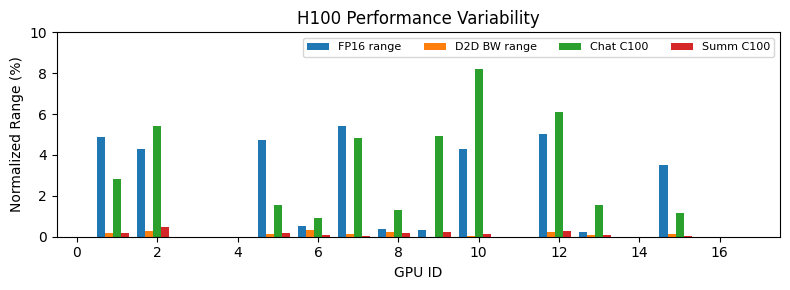

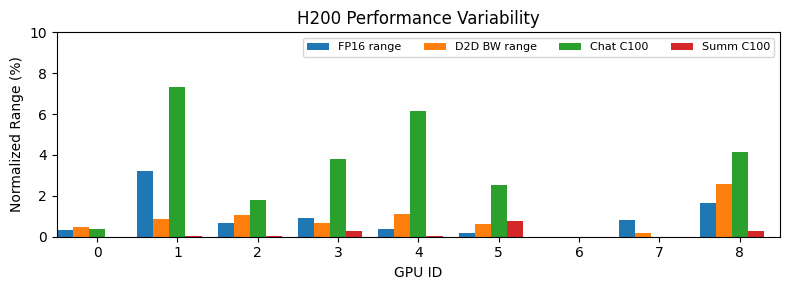

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bars_per_gpu(df, title, gpu_id_col=None):
    plot_df = df.copy()
    if gpu_id_col is not None:
        plot_df = plot_df.set_index(gpu_id_col)

    gpu_ids = plot_df.index.astype(str)
    x = np.arange(len(gpu_ids))

    metrics = [
        ("fp16_norm_range", "FP16 range"),
        ("bw_norm_range", "D2D BW range"),
        # ("tps_chat_con1", "Chat C1"),
        # ("tps_chat_con25", "Chat C25"),
        # ("tps_chat_con50", "Chat C50"),
        ("tps_chat_con100", "Chat C100"),
        # ("tps_summ_con1", "Summ C1"),
        # ("tps_summ_con25", "Summ C25"),
        # ("tps_summ_con50", "Summ C50"),
        ("tps_summ_con100", "Summ C100"),
    ]

    n_metrics = len(metrics)
    width = 0.8 / n_metrics  # total group width = 0.8

    plt.figure(figsize=(8, 3))

    for i, (col, label) in enumerate(metrics):
        values = plot_df[col].values
        mask = values != 0  # EXCLUDE zeros
        plt.bar(
            x[mask] + (i - n_metrics / 2) * width,
            values[mask],
            width,
            label=label
        )


    plt.xlabel("GPU ID")
    plt.ylabel("Normalized Range (%)")
    plt.title(title)
    plt.xlim(-0.5, len(gpu_ids) - 0.5)
    plt.ylim(0, 10)
    # plt.xticks([])          # REMOVE x ticks
    plt.legend(ncol=5, fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()


plot_bars_per_gpu(summary_h100, title="H100 Performance Variability", gpu_id_col="gpu_id")
plot_bars_per_gpu(summary_h200, title="H200 Performance Variability", gpu_id_col="gpu_id")

### Boxplot: Overall Performance Variability (H100 vs H200)

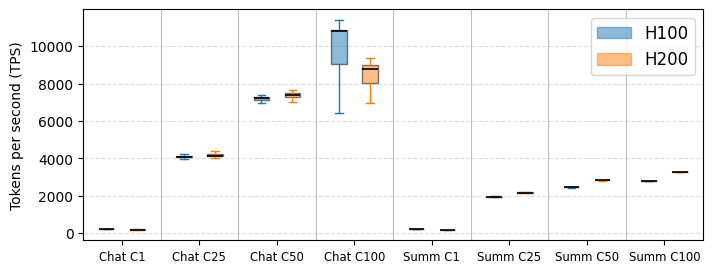

In [27]:
import pandas as pd
import numpy as np

# -----------------------
# Column definitions
# -----------------------
fp16_col = "fp16"
bw_col = "memory_bandwidth"

chat_con1 = "128_128_con_1_tps"
chat_con25 = "128_128_con_25_tps"
chat_con50 = "128_128_con_50_tps"
chat_con100 = "128_128_con_100_tps"
summ_con1 = "4096_512_con_1_tps"
summ_con25 = "4096_512_con_25_tps"
summ_con50 = "4096_512_con_50_tps"
summ_con100 = "4096_512_con_100_tps"

categories = [
    # ("FP16", fp16_col),
    # ("BW", bw_col),
    ("Chat C1", chat_con1),
    ("Chat C25", chat_con25),
    ("Chat C50", chat_con50),
    ("Chat C100", chat_con100),
    ("Summ C1", summ_con1),
    ("Summ C25", summ_con25),
    ("Summ C50", summ_con50),
    ("Summ C100", summ_con100),
]

models = ["H100", "H200"]
colors = {
    "H100": "#1f77b4",  # blue
    "H200": "#ff7f0e",  # orange
}

rows = []

for label, col in categories:
    for model in models:
        df_m = df[df["gpu_model"].str.contains(model)]
        mean_val = df_m[col].mean()

        for v in df_m[col].dropna():
            rows.append({
                "metric": label,
                "model": model,
                "perf": v
            })

df_long = pd.DataFrame(rows)

metrics = [c[0] for c in categories]
x_pos = np.arange(len(metrics))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(8, 3))

for i, model in enumerate(models):
    data = [
        df_long[
            (df_long["metric"] == m) &
            (df_long["model"] == model)
        ]["perf"].values
        for m in metrics
    ]

    ax.boxplot(
        data,
        positions=x_pos + (i - 0.5) * 0.4,
        widths=bar_width,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(
            facecolor=colors[model],
            alpha=0.5
        ),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color=colors[model]),
        capprops=dict(color=colors[model]),
    )

# Add xgrid line
for i in range(1, len(metrics)):
    ax.axvline(i - 0.5, linewidth=0.8, alpha=0.5, color='gray')

ax.set_xticks(x_pos)
ax.set_xlim(-0.5, len(metrics) - 0.5)
ax.set_xticklabels(metrics, ha="center", fontsize="small")
ax.set_ylabel("Tokens per second (TPS)")
# ax.set_title("Intra-model Performance Variability (H100 vs H200)")

ax.grid(axis="y", linestyle="--", alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors["H100"], alpha=0.5, edgecolor=colors["H100"], label='H100'),
    Patch(facecolor=colors["H200"], alpha=0.5, edgecolor=colors["H200"], label='H200')
]
ax.legend(handles=legend_elements, loc='best', frameon=True, fontsize=12)

plt.savefig("tps_llama3-4b_all_boxplot.pdf", dpi=600, bbox_inches='tight')
plt.show()

### Regression by GPU ID

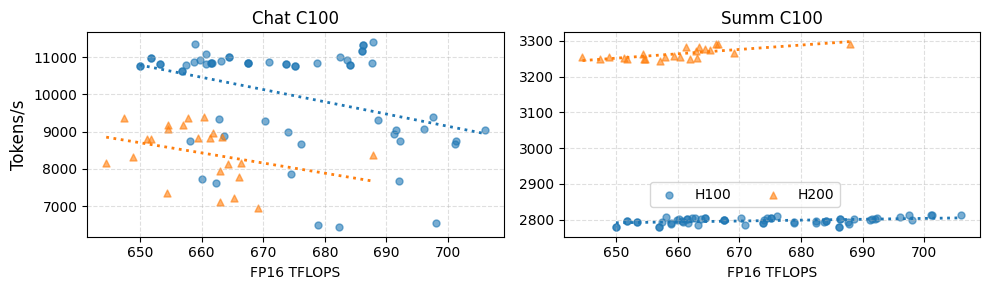

In [28]:
import matplotlib.pyplot as plt

fp16_col = "fp16"
tps_cols = [
    # "128_128_con_1_tps",
    "128_128_con_100_tps",
    # "4096_512_con_1_tps",
    "4096_512_con_100_tps",
]

tps_title_map = {
    # "128_128_con_1_tps": "Chat C1",
    "128_128_con_100_tps": "Chat C100",
    # "4096_512_con_1_tps": "Summ C1",
    "4096_512_con_100_tps": "Summ C100",
}

df_h100 = df[df["gpu_model"].str.contains("H100")]
df_h200 = df[df["gpu_model"].str.contains("H200")]

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 3),
    sharex=True,
)

axes = axes.flatten()

for ax, tps_col in zip(axes, tps_cols):
    # H100
    ax.scatter(
        df_h100[fp16_col],
        df_h100[tps_col],
        alpha=0.6,
        s=25,
        marker="o",
        label="H100",
    )

    # H200
    ax.scatter(
        df_h200[fp16_col],
        df_h200[tps_col],
        alpha=0.6,
        s=25,
        marker="^",
        label="H200",
    )

    # ---------- H100 regression ----------
    x_h100 = df_h100[fp16_col].values
    y_h100 = df_h100[tps_col].values
    mask_h100 = y_h100 > 0  # optional: exclude zeros

    if mask_h100.sum() > 1:
        coef_h100 = np.polyfit(x_h100[mask_h100], y_h100[mask_h100], 1)
        x_fit = np.linspace(x_h100.min(), x_h100.max(), 100)
        y_fit = coef_h100[0] * x_fit + coef_h100[1]
        ax.plot(x_fit, y_fit, linestyle=":", linewidth=2)

    # ---------- H200 regression ----------
    x_h200 = df_h200[fp16_col].values
    y_h200 = df_h200[tps_col].values
    mask_h200 = y_h200 > 0  # optional: exclude zeros

    if mask_h200.sum() > 1:
        coef_h200 = np.polyfit(x_h200[mask_h200], y_h200[mask_h200], 1)
        x_fit = np.linspace(x_h200.min(), x_h200.max(), 100)
        y_fit = coef_h200[0] * x_fit + coef_h200[1]
        ax.plot(x_fit, y_fit, linestyle=":", linewidth=2)

    ax.set_title(tps_title_map[tps_col])
    if ax in axes[0:]:
        ax.set_xlabel("FP16 TFLOPS")
    ax.grid(True, linestyle="--", alpha=0.4)

# Shared y-label
axes[0].set_ylabel("Tokens/s", fontsize=12)
# axes[len(axes)//2].set_ylabel("Tokens/s", fontsize=12)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.75, 0.4),  # (x, y) in figure coordinates
    ncol=2,
    fontsize="medium",
    frameon=True,
)

plt.savefig("tps_vs_fp16_llama3-4b_scatter.pdf", dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


### Boxplots of FP16 vs TPS (Chat C100)

In [31]:
fp16_col = "fp16"
tps_col = "128_128_con_100_tps"

aggregate_method = "mean"  # or "median", "max"

df_h100 = df[df["gpu_model"].str.contains("H100")].copy()

df_h100["fp16_norm"] = (
    df_h100[fp16_col] /
    df_h100.groupby("gpu_id")[fp16_col].transform(aggregate_method)
)

df_h100["tps_norm"] = (
    df_h100[tps_col] /
    df_h100.groupby("gpu_id")[tps_col].transform(aggregate_method)
)

df_h200 = df[df["gpu_model"].str.contains("H200")].copy()

df_h200["fp16_norm"] = (
    df_h200[fp16_col] /
    df_h200.groupby("gpu_id")[fp16_col].transform(aggregate_method)
)

df_h200["tps_norm"] = (
    df_h200[tps_col] /
    df_h200.groupby("gpu_id")[tps_col].transform(aggregate_method)
)

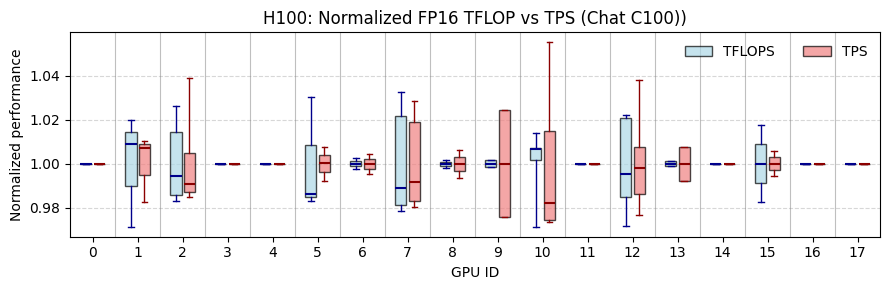

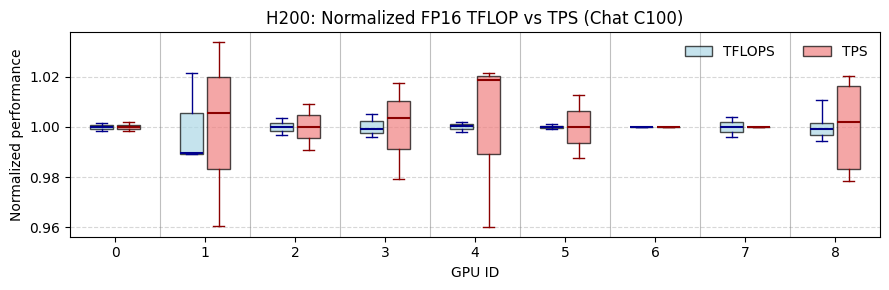

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def boxplot_fp16_tps_one_cell(
    df,
    title,
):
    gpu_ids = sorted(df["gpu_id"].unique())
    n = len(gpu_ids)

    fp16_data = [
        df.loc[df["gpu_id"] == gid, "fp16_norm"].dropna().values
        for gid in gpu_ids
    ]
    tps_data = [
        df.loc[df["gpu_id"] == gid, "tps_norm"].dropna().values
        for gid in gpu_ids
    ]

    # Boxplot positions
    dx = 0.15
    x_positions = np.arange(n)      
    pos_fp16 = x_positions - dx
    pos_tps = x_positions + dx

    plt.figure(figsize=(9, 3))

    bp1 = plt.boxplot(
        fp16_data,
        positions=pos_fp16,
        widths=0.25,
        patch_artist=True,
        showfliers=True,
        whis=(0, 100),  # whiskers to min/max
        boxprops=dict(facecolor='lightblue', alpha=0.7),
        medianprops=dict(color='darkblue', linewidth=1.5),
        whiskerprops=dict(color='darkblue', linewidth=1),
        capprops=dict(color='darkblue', linewidth=1)
    )

    bp2 = plt.boxplot(
        tps_data,
        positions=pos_tps,
        widths=0.25,
        patch_artist=True,
        showfliers=True,
        whis=(0, 100),
        boxprops=dict(facecolor='lightcoral', alpha=0.7),
        medianprops=dict(color='darkred', linewidth=1.5),
        whiskerprops=dict(color='darkred', linewidth=1),
        capprops=dict(color='darkred', linewidth=1)
    )
    # Add vertical grid lines
    for x in range(1, n):
        plt.axvline(x - 0.5, linewidth=0.8, alpha=0.5, color='gray')

    plt.xticks(
        x_positions,
        range(len(gpu_ids))
    )

    plt.ylabel("Normalized performance")
    plt.xlabel("GPU ID")
    plt.xlim(-0.5, len(x_positions) - 0.5)
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.legend(
        [bp1["boxes"][0], bp2["boxes"][0]],
        ["TFLOPS", "TPS"],
        ncol=2,
        frameon=False,
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()

boxplot_fp16_tps_one_cell(
    df_h100,
    title="H100: Normalized FP16 TFLOP vs TPS (Chat C100))"
)

boxplot_fp16_tps_one_cell(
    df_h200,
    title="H200: Normalized FP16 TFLOP vs TPS (Chat C100)"
)


#### Linear regression

In [ ]:
import sklearn
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def linear_regression_analysis(
    dd: pd.DataFrame,
    x_field: str,
    y_field: str,
    model_name: str
):
    # Select valid rows
    mask = (
        dd[x_field].notna()
        & dd[y_field].notna()
    )

    X = dd.loc[mask, [x_field]].values
    y = dd.loc[mask, y_field].values

    # Fit linear model
    model = LinearRegression()
    model.fit(X, y)

    # Predictions
    y_pred = model.predict(X)

    # Metrics
    coef = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(y, y_pred)

    print(f"Linear regression: {y_field} ~ {x_field} ({model_name})")
    print(f"{y_field} = {coef:.4f} * {x_field} + {intercept:.2f}")
    print(f"R^2 = {r2:.4f}")
    print()

for gpu_df, gpu_name in [(df_h100, "H100"), (df_h200, "H200")]:
    for x_field in ["fp16", "memory_bandwidth"]:
        for tps_item in TPS_COLS_CHAT + TPS_COLS_SUMMARIZATION:
            linear_regression_analysis(
                gpu_df,
                x_field,
                tps_item,
                gpu_name
            )

### Tokens/$ Analysis

In [35]:
# Real price on Jan/18, 2026
price_map = {
    "lambda" : {
        "H100": 3.29,  # $/hr
    },
    "verda" : {
        "H100": 2.29,
        "H200": 2.99
    }
}

In [44]:
target_tps = "128_128_con_100_tps"  # or "4096_512_con_100_tps"

# --- Calculate tokens/$ difference for each provider and GPU model ---
df['tokens_per_dollar'] = np.nan
for provider in price_map.keys():
    # print(f"Processing provider: {provider}, price map: {price_map[provider]}")
    for gpu_model in price_map[provider]:
        price_per_hour = price_map[provider][gpu_model]
        mask = (
            (df['provider'] == provider) &
            (df['gpu_model'].str.contains(gpu_model))
        )
        df.loc[mask, 'tokens_per_dollar'] = (
            df.loc[mask, target_tps] * 3600.0 / price_per_hour
        )

# --- Summary statistics of tokens per dollar ---
tokens_per_dollar_stats = (
    df.groupby(['provider', 'gpu_model'])['tokens_per_dollar']
      .agg(
        count='count',
        min='min',
        max='max',
        ratio_max_min=lambda s: s.max() / s.min() if s.min() > 0 else np.nan,
      )
      .reset_index()
)
print("Tokens per dollar statistics for {}:".format(target_tps))
print(tokens_per_dollar_stats)


Tokens per dollar statistics for 128_128_con_100_tps:
  provider              gpu_model  count           min           max  \
0   lambda  NVIDIA H100 80GB HBM3     25  1.163916e+07  1.238633e+07   
1    verda  NVIDIA H100 80GB HBM3     36  1.010909e+07  1.794166e+07   
2    verda            NVIDIA H200     23  8.359492e+06  1.130313e+07   

   ratio_max_min  
0       1.064195  
1       1.774804  
2       1.352132  


In [39]:
tokens_per_dollar_stats_by_model = (
    df.groupby(['gpu_model'])['tokens_per_dollar']
      .agg(
        count='count',
        min='min',
        max='max',
        ratio_max_min=lambda s: s.max() / s.min() if s.min() > 0 else np.nan,
      )
      .reset_index()
)
print("Tokens per dollar statistics by GPU model:")
print(tokens_per_dollar_stats_by_model)


Tokens per dollar statistics by GPU model:
               gpu_model  count           min           max  ratio_max_min
0  NVIDIA H100 80GB HBM3     61  1.010909e+07  1.794166e+07       1.774804
1            NVIDIA H200     23  8.359492e+06  1.130313e+07       1.352132


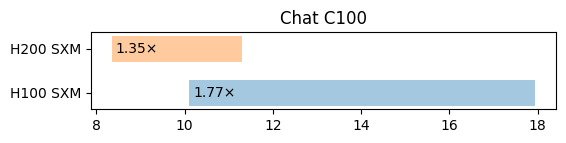

In [41]:
import matplotlib.pyplot as plt

"""
Tokens per dollar statistics by GPU model:
               gpu_model  count           min           max  ratio_max_min
0  NVIDIA H100 80GB HBM3     61  1.010909e+07  1.794166e+07       1.774804
1            NVIDIA H200     23  8.359492e+06  1.130313e+07       1.352132
"""

TOKEN_BASE = 1e6  # for scaling tokens to millions

models = ["H100 SXM", "H200 SXM"]
mins   = [1.010909e+07, 8.359492e+06]
mins  = [m / TOKEN_BASE for m in mins]
maxs   = [1.794166e+07, 1.130313e+07]
maxs  = [m / TOKEN_BASE for m in maxs]
ratios = [1.774804, 1.352132]


y_pos = [0, 1]
dy = 0.3

fig, ax = plt.subplots(figsize=(6, 1))

for y, model, xmin, xmax, ratio in zip(y_pos, models, mins, maxs, ratios):
    ax.fill_betweenx(
        [y - dy, y + dy],
        xmin,
        xmax,
        alpha=0.4
    )
    ax.text(xmin * 1.01, y, f"{ratio:.2f}×", va="center", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
# ax.set_xlabel("Million tokens per dollar")
ax.set_title("Chat C100")

plt.savefig(f"tokens_per_dollar_range_llama3-4b_{target_tps}.pdf", dpi=600, bbox_inches='tight')
plt.show()

In [42]:
target_tps = "4096_512_con_100_tps"  # or "4096_512_con_100_tps"

# --- Calculate tokens/$ difference for each provider and GPU model ---
df['tokens_per_dollar'] = np.nan
for provider in price_map.keys():
    print(f"Processing provider: {provider}, price map: {price_map[provider]}")
    for gpu_model in price_map[provider]:
        price_per_hour = price_map[provider][gpu_model]
        mask = (
            (df['provider'] == provider) &
            (df['gpu_model'].str.contains(gpu_model))
        )
        df.loc[mask, 'tokens_per_dollar'] = (
            df.loc[mask, target_tps] * 3600 / price_per_hour
        )

# --- Summary statistics of tokens per dollar ---
tokens_per_dollar_stats = (
    df.groupby(['gpu_model'])['tokens_per_dollar']
      .agg(
        count='count',
        min='min',
        max='max',
        ratio_max_min=lambda s: s.max() / s.min() if s.min() > 0 else np.nan,
      )
      .reset_index()
)
print("Tokens per dollar statistics for {}:".format(target_tps))
print(tokens_per_dollar_stats)

Processing provider: lambda, price map: {'H100': 3.29}
Processing provider: verda, price map: {'H100': 2.29, 'H200': 2.99}
Tokens per dollar statistics for 4096_512_con_100_tps:
               gpu_model  count           min           max  ratio_max_min
0  NVIDIA H100 80GB HBM3     61  3.039700e+06  4.422232e+06       1.454825
1            NVIDIA H200     23  3.906461e+06  3.963732e+06       1.014661


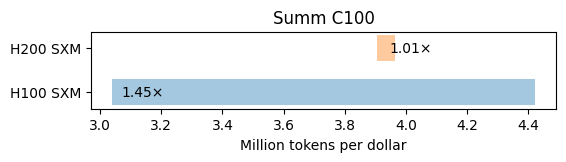

In [43]:
'''
Processing provider: lambda, price map: {'H100': 3.29}
Processing provider: verda, price map: {'H100': 2.29, 'H200': 2.99}
Tokens per dollar statistics:
               gpu_model  count           min           max  ratio_max_min
0  NVIDIA H100 80GB HBM3     61  3.039700e+06  4.422232e+06       1.454825
1            NVIDIA H200     23  3.906461e+06  3.963732e+06       1.014661
'''

models = ["H100 SXM", "H200 SXM"]
mins   = [3.039700e+06, 3.906461e+06]
mins  = [m / TOKEN_BASE for m in mins]
maxs   = [4.422232e+06, 3.963732e+06]
maxs  = [m / TOKEN_BASE for m in maxs]
ratios = [1.454825, 1.014661]

y_pos = [0, 1]
dy = 0.3

fig, ax = plt.subplots(figsize=(6, 1))

for y, model, xmin, xmax, ratio in zip(y_pos, models, mins, maxs, ratios):
    ax.fill_betweenx(
        [y - dy, y + dy],
        xmin,
        xmax,
        alpha=0.4
    )
    ax.text(xmin * 1.01, y, f"{ratio:.2f}×", va="center", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.set_xlabel("Million tokens per dollar")
ax.set_title("Summ C100")

plt.savefig(f"tokens_per_dollar_range_llama3-4b_{target_tps}.pdf", dpi=600, bbox_inches='tight')
plt.show()



